# Libraries

In [2]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
from google.colab import drive, files
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb

# Settings
sns.set(style="whitegrid")


# Dataset Upload

In [3]:
def upload_from_local():
    print("Please upload your CSV file:")
    uploaded = files.upload()
    file_name = next(iter(uploaded))
    return pd.read_csv(file_name)

# Upload file directly from local machine
df = upload_from_local()

# Display dataset preview
print("\nDataset preview:")
print(df.head())

Please upload your CSV file:


Saving cardio_data.csv to cardio_data.csv

Dataset preview:
         date    country  id  active    age  alco  ap_hi  ap_lo  cholesterol  \
0  03-05-2021  Indonesia   0       1  18393     0    110     80            1   
1  05-08-2021   Malaysia   1       1  20228     0    140     90            3   
2  13-11-2022  Indonesia   2       0  18857     0    130     70            3   
3  31-10-2018  Singapore   3       1  17623     0    150    100            1   
4  25-09-2020  Singapore   4       0  17474     0    100     60            1   

   gender  gluc  height  occupation  smoke  weight  disease  
0       2     1     168   Architect      0    62.0        0  
1       1     1     156  Accountant      0    85.0        1  
2       1     1     165        Chef      0    64.0        1  
3       2     1     169      Lawyer      0    82.0        1  
4       1     1     156   Architect      0    56.0        0  


# Data Overview

In [4]:
df.columns

Index(['date', 'country', 'id', 'active', 'age', 'alco', 'ap_hi', 'ap_lo',
       'cholesterol', 'gender', 'gluc', 'height', 'occupation', 'smoke',
       'weight', 'disease'],
      dtype='object')

In [5]:
# Shape and info
print("Dataset shape:", df.shape)
df.info()

# Summary statistics
df.describe()

Dataset shape: (70000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         70000 non-null  object 
 1   country      70000 non-null  object 
 2   id           70000 non-null  int64  
 3   active       70000 non-null  int64  
 4   age          70000 non-null  int64  
 5   alco         70000 non-null  int64  
 6   ap_hi        70000 non-null  int64  
 7   ap_lo        70000 non-null  int64  
 8   cholesterol  70000 non-null  int64  
 9   gender       70000 non-null  int64  
 10  gluc         70000 non-null  int64  
 11  height       70000 non-null  int64  
 12  occupation   70000 non-null  object 
 13  smoke        70000 non-null  int64  
 14  weight       70000 non-null  float64
 15  disease      70000 non-null  int64  
dtypes: float64(1), int64(12), object(3)
memory usage: 8.5+ MB


,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,smoke,weight,disease
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,0.803729,19468.865814,0.053771,128.817286,96.630414,1.366871,1.349571,1.226457,164.359229,0.088129,74.205690,0.499700
std,28851.302323,0.397179,2467.251667,0.225568,154.011419,188.472530,0.680250,0.476838,0.572270,8.210126,0.283484,14.395757,0.500003
min,0.000000,0.000000,10798.000000,0.000000,-150.000000,-70.000000,1.000000,1.000000,1.000000,55.000000,0.000000,10.000000,0.000000
25%,25006.750000,1.000000,17664.000000,0.000000,120.000000,80.000000,1.000000,1.000000,1.000000,159.000000,0.000000,65.000000,0.000000
50%,50001.500000,1.000000,19703.000000,0.000000,120.000000,80.000000,1.000000,1.000000,1.000000,165.000000,0.000000,72.000000,0.000000
75%,74889.250000,1.000000,21327.000000,0.000000,140.000000,90.000000,2.000000,2.000000,1.000000,170.000000,0.000000,82.000000,1.000000
max,99999.000000,1.000000,23713.000000,1.000000,16020.000000,11000.000000,3.000000,2.000000,3.000000,250.000000,1.000000,200.000000,1.000000


# Checking for missing values & duplicates

In [6]:
df.isnull().sum()

,0
date,0
country,0
id,0
active,0
age,0
alco,0
ap_hi,0
ap_lo,0
cholesterol,0
gender,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# EDA

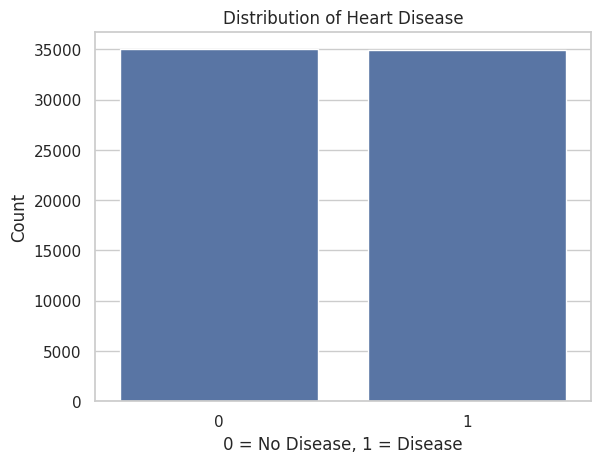

In [7]:
# Distribution of target (heart disease presence)
sns.countplot(x='disease', data=df)
plt.title("Distribution of Heart Disease")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Count")
plt.show()

# Feature Engineering & Preprocessing

In [8]:
# Separate features and target
X = df.drop('disease', axis=1)
y = df['disease']

In [9]:
# Drop non-informative or identifier columns
X = X.drop(columns=['date', 'country', 'id', 'occupation'], errors='ignore')

In [10]:
# Scaling the features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Models

## Model Training

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(probability=True),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

## Model Evaluation

In [12]:
# Store results
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    results.append([name, acc, roc])

    print(f"\n {name} Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


 Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.75      0.72      7004
           1       0.73      0.68      0.70      6996

    accuracy                           0.71     14000
   macro avg       0.72      0.71      0.71     14000
weighted avg       0.72      0.71      0.71     14000

Confusion Matrix:
 [[5271 1733]
 [2273 4723]]

 Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.63      0.63      7004
           1       0.63      0.63      0.63      6996

    accuracy                           0.63     14000
   macro avg       0.63      0.63      0.63     14000
weighted avg       0.63      0.63      0.63     14000

Confusion Matrix:
 [[4425 2579]
 [2578 4418]]

 Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.73      0.72      7004
           1       0.7

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:04:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



 XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.77      0.74      7004
           1       0.75      0.69      0.72      6996

    accuracy                           0.73     14000
   macro avg       0.73      0.73      0.73     14000
weighted avg       0.73      0.73      0.73     14000

Confusion Matrix:
 [[5390 1614]
 [2140 4856]]


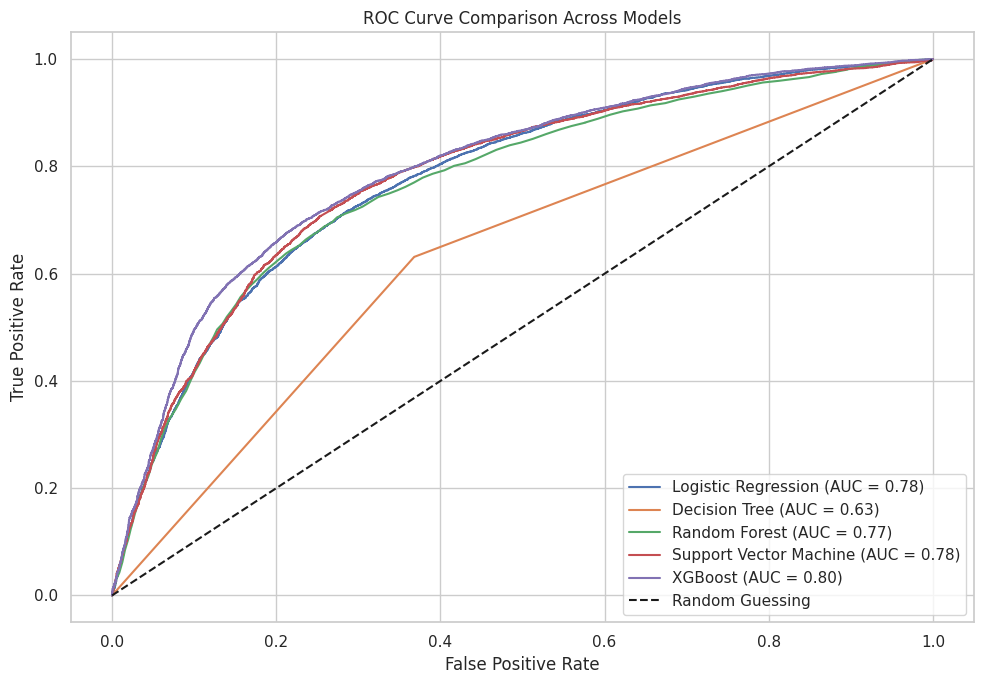

In [13]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.title("ROC Curve Comparison Across Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

1. XGBoost performs the best among the models with an AUC of 0.80, meaning it has the highest ability to distinguish between the classes.

2. Logistic Regression and SVM are tied with strong performance (AUC = 0.78).

3. Random Forest is just slightly behind (AUC = 0.77).

4. Decision Tree lags significantly (AUC = 0.63), suggesting it's not as reliable on this dataset.

5. The black dashed diagonal line represents a random guess (AUC = 0.50). All models perform better than random guessing, which is good.

## Comparison of Models

In [14]:
# Display comparison
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC-AUC"])
results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

,Model,Accuracy,ROC-AUC
0,XGBoost,0.731857,0.795457
1,Support Vector Machine,0.725357,0.782487
2,Logistic Regression,0.713857,0.778127
3,Random Forest,0.715429,0.770654
4,Decision Tree,0.631643,0.631583


# Features

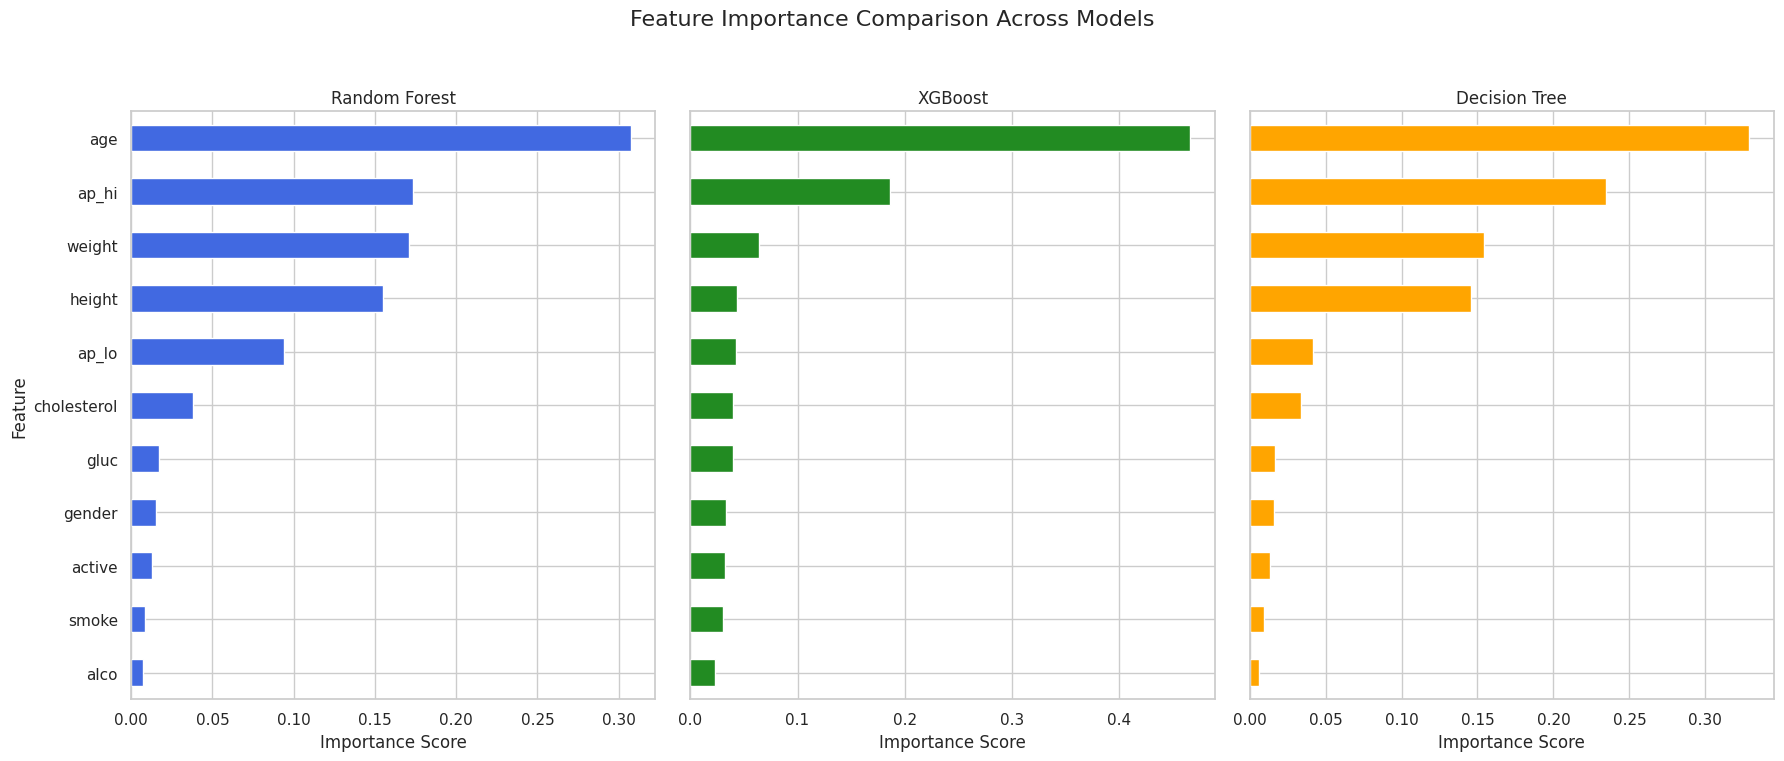

In [15]:
# Prepare importances
rf_imp = pd.Series(models["Random Forest"].feature_importances_, index=X.columns).sort_values(ascending=True)
xgb_imp = pd.Series(models["XGBoost"].feature_importances_, index=X.columns).sort_values(ascending=True)
dt_imp = pd.Series(models["Decision Tree"].feature_importances_, index=X.columns).sort_values(ascending=True)

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)

rf_imp.plot(kind='barh', ax=axes[0], color='royalblue')
axes[0].set_title("Random Forest")
axes[0].set_xlabel("Importance Score")
axes[0].set_ylabel("Feature")

xgb_imp.plot(kind='barh', ax=axes[1], color='forestgreen')
axes[1].set_title("XGBoost")
axes[1].set_xlabel("Importance Score")

dt_imp.plot(kind='barh', ax=axes[2], color='orange')
axes[2].set_title("Decision Tree")
axes[2].set_xlabel("Importance Score")

fig.suptitle("Feature Importance Comparison Across Models", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Top 5 features

In [16]:
# Get feature importances from models that support it
rf_imp = pd.Series(models["Random Forest"].feature_importances_, index=X.columns)
xgb_imp = pd.Series(models["XGBoost"].feature_importances_, index=X.columns)
dt_imp = pd.Series(models["Decision Tree"].feature_importances_, index=X.columns)

# Normalize importances (so all models are on the same scale)
rf_imp = rf_imp / rf_imp.sum()
xgb_imp = xgb_imp / xgb_imp.sum()
dt_imp = dt_imp / dt_imp.sum()

# Combine into a single DataFrame
importances_df = pd.DataFrame({
    'Random Forest': rf_imp,
    'XGBoost': xgb_imp,
    'Decision Tree': dt_imp
})

# Calculate average importance across models
importances_df['Average'] = importances_df.mean(axis=1)

# Get top 5 features
top_5_avg = importances_df['Average'].sort_values(ascending=False).head(5)
print("Top 5 Features (Averaged Across Models):")
print(top_5_avg)

Top 5 Features (Averaged Across Models):
ap_hi          0.290532
age            0.233240
weight         0.119318
height         0.107894
cholesterol    0.085976
Name: Average, dtype: float64


# Final Summary

In [ ]:
# Best model summary
best_model = results_df.loc[results_df['ROC-AUC'].idxmax()]
print(f"\n🏆 Best Performing Model: {best_model['Model']}")
print(f"Accuracy: {best_model['Accuracy']:.4f}")
print(f"ROC-AUC: {best_model['ROC-AUC']:.4f}")


🏆 Best Performing Model: XGBoost
Accuracy: 0.7319
ROC-AUC: 0.7955


XGBoost delivered the best performance, especially in terms of ROC-AUC, meaning it’s highly effective at distinguishing patients with and without disease. Although SVM and Logistic Regression also performed well, XGBoost offers the best balance of predictive power and robustness. We recommend XGBoost for deployment, with Logistic Regression as a strong interpretable backup model.

**Conclusion**

In this project, I developed and evaluated several machine learning models to predict the presence of heart disease using a dataset that included both medical and lifestyle variables. The objective was to accurately classify individuals as either having or not having heart disease based on factors such as age, cholesterol levels, blood pressure, glucose, and other lifestyle-related attributes.

Among the five models evaluated—XGBoost, Support Vector Machine, Logistic Regression, Random Forest, and Decision Tree—XGBoost emerged as the most effective, achieving the highest ROC-AUC score of 0.795 and an accuracy of approximately 73.2%. This indicates that XGBoost was the best at distinguishing between individuals with and without heart disease.

Key features that contributed significantly to prediction included systolic blood pressure, age, cholesterol levels, and weight. These insights are consistent with existing clinical knowledge, reinforcing the reliability of the model's outputs.

**Recommendations**

Based on the analysis, I recommend XGBoost for deployment in predictive healthcare systems where performance is critical. However, Logistic Regression and Random Forest are also strong candidates, particularly when interpretability and ease of use are essential. Decision Trees, while useful for exploratory analysis, are not recommended as standalone models due to their lower predictive performance.

**Future Work**

While the current results are promising, several directions can be pursued to improve and extend this study:

1. Feature Expansion: Additional variables such as exercise frequency, diet, medication use, and family history of heart disease could enhance model performance.

2. Hyperparameter Tuning: Further optimization of model parameters, especially for complex models like XGBoost and SVM, could lead to performance gains.

3. Cross-Validation: Implementing k-fold cross-validation would ensure more robust model evaluation and generalizability.

4. Imbalanced Data Handling: Techniques such as SMOTE or class weighting could improve model sensitivity to minority cases if class imbalance becomes an issue in future datasets.